# Sequence Model

|         |                               |
| :------ | :---------------------------- |
| Dataset | Epileptic Seizure Recognition |
| Model   | BiLSTM                        |

In [1]:
# ============================================================
# BLOK 1 - IMPORT LIBRARY
# ============================================================

import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

warnings.filterwarnings("ignore")
plt.style.use("ggplot")

2026-04-19 12:31:55.441411: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776601915.657006      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776601915.720746      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776601916.229393      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776601916.229427      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776601916.229430      22 computation_placer.cc:177] computation placer alr

## Blok 1

Mengimpor library utama untuk:
- membaca dataset
- preprocessing
- membangun model TensorFlow
- training
- evaluasi
- visualisasi hasil

In [2]:

# ============================================================
# BLOK 2 - KONFIGURASI
# ============================================================

SEED = 42
MODEL_NAME = "BiLSTM"

VAL_SIZE = 0.15
TEST_SIZE = 0.15

BATCH_SIZE = 32
EPOCHS = 40
LEARNING_RATE = 8e-4

EMBED_DIM = 32
BILSTM_UNITS_1 = 160
BILSTM_UNITS_2 = 96
INPUT_DROPOUT = 0.05
REC_DROPOUT_1 = 0.10
REC_DROPOUT_2 = 0.10
ATTN_HEADS = 4
ATTN_KEY_DIM = 24
ATTN_DROPOUT = 0.10
FFN_UNITS = 192
FFN_DROPOUT = 0.20
DENSE_UNITS = 128
DENSE_DROPOUT = 0.25
L2_FACTOR = 1e-4

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print({
    "MODEL_NAME": MODEL_NAME,
    "VAL_SIZE": VAL_SIZE,
    "TEST_SIZE": TEST_SIZE,
    "BATCH_SIZE": BATCH_SIZE,
    "EPOCHS": EPOCHS,
    "LEARNING_RATE": LEARNING_RATE,
    "EMBED_DIM": EMBED_DIM,
    "BILSTM_UNITS_1": BILSTM_UNITS_1,
    "BILSTM_UNITS_2": BILSTM_UNITS_2,
    "INPUT_DROPOUT": INPUT_DROPOUT,
    "REC_DROPOUT_1": REC_DROPOUT_1,
    "REC_DROPOUT_2": REC_DROPOUT_2,
    "ATTN_HEADS": ATTN_HEADS,
    "ATTN_KEY_DIM": ATTN_KEY_DIM,
    "ATTN_DROPOUT": ATTN_DROPOUT,
    "FFN_UNITS": FFN_UNITS,
    "FFN_DROPOUT": FFN_DROPOUT,
    "DENSE_UNITS": DENSE_UNITS,
    "DENSE_DROPOUT": DENSE_DROPOUT,
    "L2_FACTOR": L2_FACTOR,
})


{'MODEL_NAME': 'BiLSTM', 'VAL_SIZE': 0.15, 'TEST_SIZE': 0.15, 'BATCH_SIZE': 32, 'EPOCHS': 40, 'LEARNING_RATE': 0.0008, 'EMBED_DIM': 32, 'BILSTM_UNITS_1': 160, 'BILSTM_UNITS_2': 96, 'INPUT_DROPOUT': 0.05, 'REC_DROPOUT_1': 0.1, 'REC_DROPOUT_2': 0.1, 'ATTN_HEADS': 4, 'ATTN_KEY_DIM': 24, 'ATTN_DROPOUT': 0.1, 'FFN_UNITS': 192, 'FFN_DROPOUT': 0.2, 'DENSE_UNITS': 128, 'DENSE_DROPOUT': 0.25, 'L2_FACTOR': 0.0001}


## Blok 2
Menentukan parameter eksperimen

Konfigurasi model:
- embedding temporal sebelum recurrent block
- BiLSTM bertingkat dua dengan residual
- self-attention dan feed-forward residual
- regularisasi moderat untuk menjaga generalisasi


In [3]:
# ============================================================
# BLOK 3 - MENCARI FILE DATASET DI /kaggle/input
# ============================================================

ROOT_INPUT = Path("/kaggle/input")

def score_csv_path(path_obj):
    name = path_obj.name.lower()
    score = 0

    exact_priority = [
        "epileptic seizure recognition.csv",
        "epileptic_seizure_recognition.csv",
        "data.csv",
    ]
    if name in exact_priority:
        score += 100 - exact_priority.index(name) * 10

    if "epileptic" in name:
        score += 30
    if "seizure" in name:
        score += 30
    if "recognition" in name:
        score += 20
    if "eeg" in name:
        score += 10

    return score

def looks_like_epileptic_schema(path_obj):
    try:
        sample_df = pd.read_csv(path_obj, nrows=5)
    except Exception:
        return False

    cols = [str(c).strip().lower() for c in sample_df.columns]
    has_target = ("y" in cols) or ("label" in cols) or ("target" in cols) or (len(cols) >= 2)
    enough_columns = len(cols) >= 100
    return has_target and enough_columns

def search_candidate_csv():
    if not ROOT_INPUT.exists():
        raise FileNotFoundError("Folder /kaggle/input tidak ditemukan.")

    all_csv = list(ROOT_INPUT.rglob("*.csv"))
    if not all_csv:
        raise FileNotFoundError("Tidak ada file CSV yang ditemukan di /kaggle/input.")

    scored = []
    for p in all_csv:
        score = score_csv_path(p)
        if score > 0 and looks_like_epileptic_schema(p):
            scored.append((score, str(p), p))

    if not scored:
        fallback = [p for p in all_csv if looks_like_epileptic_schema(p)]
        if not fallback:
            raise FileNotFoundError("File dataset Epileptic Seizure Recognition tidak ditemukan.")
        fallback = sorted(fallback, key=lambda p: (score_csv_path(p), str(p)), reverse=True)
        return fallback[0]

    scored = sorted(scored, key=lambda x: (x[0], x[1]), reverse=True)
    return scored[0][2]

data_path = search_candidate_csv()
print("Dataset path:", data_path)

Dataset path: /kaggle/input/datasets/yasserhessein/epileptic-seizure-recognition/Epileptic Seizure Recognition.csv


## Blok 3

Pencarian file dibuat otomatis di `/kaggle/input`, tetapi prioritas diarahkan ke file CSV utama dataset **Epileptic Seizure Recognition** agar tidak tertukar dengan file lain.


In [4]:

# ============================================================
# BLOK 4 - MEMBACA DATASET
# ============================================================

df = pd.read_csv(data_path)

print("Shape awal:", df.shape)
display(df.head())
print("\nNama kolom:")
print(df.columns.tolist()[:10], "...", df.columns.tolist()[-10:])

Shape awal: (11500, 180)


,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5



Nama kolom:
['Unnamed', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9'] ... ['X170', 'X171', 'X172', 'X173', 'X174', 'X175', 'X176', 'X177', 'X178', 'y']


## Blok 4

Dataset dibaca dari satu file CSV utama. Pengecekan awal dilakukan untuk melihat bentuk tabel, nama kolom, dan struktur umum data.

In [5]:
# ============================================================
# BLOK 5 - MEMBERSIHKAN STRUKTUR KOLOM
# ============================================================

df = df.copy()

# Hapus kolom indeks tambahan jika ada
first_col = str(df.columns[0]).strip().lower()
if "unnamed" in first_col:
    df = df.drop(columns=df.columns[0])

# Pastikan kolom target ditemukan
target_col = None
for col in df.columns:
    col_lower = str(col).strip().lower()
    if col_lower in ["y", "label", "target"]:
        target_col = col
        break

if target_col is None:
    target_col = df.columns[-1]

raw_feature_cols = [c for c in df.columns if c != target_col]

# Konversi fitur ke numerik dan buang kolom non-numerik yang tidak valid
numeric_features = df[raw_feature_cols].apply(pd.to_numeric, errors="coerce")
valid_ratio = numeric_features.notna().mean(axis=0)

drop_feature_cols = valid_ratio[valid_ratio < 0.95].index.tolist()
if drop_feature_cols:
    print("Kolom fitur dibuang karena non-numerik / tidak valid:", drop_feature_cols)

feature_cols = [c for c in raw_feature_cols if c not in drop_feature_cols]

df = pd.concat(
    [
        numeric_features[feature_cols],
        pd.to_numeric(df[target_col], errors="coerce").rename(target_col),
    ],
    axis=1,
)

df = df.dropna(axis=0).reset_index(drop=True)

print("Shape setelah cleaning:", df.shape)
print("Kolom target:", target_col)
print("Jumlah fitur:", len(feature_cols))
display(df.head())

Shape setelah cleaning: (11500, 179)
Kolom target: y
Jumlah fitur: 178


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,135,190,229,223,192,125,55,-9,-33,-38,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,386,382,356,331,320,315,307,272,244,232,...,164,150,146,152,157,156,154,143,129,1
2,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


## Blok 5

Kolom indeks tambahan dibuang bila ada. Fitur yang tidak valid atau tidak dapat diubah menjadi numerik juga dibuang agar struktur sequence tetap konsisten.


In [6]:

# ============================================================
# BLOK 6 - MEMISAHKAN FITUR DAN LABEL
# ============================================================

X = df[feature_cols].to_numpy(dtype="float32")
y = df[target_col].to_numpy()

print("Shape fitur :", X.shape)
print("Shape target:", y.shape)
print("Label unik  :", np.unique(y))

Shape fitur : (11500, 178)
Shape target: (11500,)
Label unik  : [1 2 3 4 5]


## Blok 6

Setiap baris merepresentasikan satu segmen sinyal EEG. Fitur berisi deret nilai sinyal, sedangkan kolom target berisi kelas aktivitas otak.

,label,jumlah_sampel
0,1,2300
1,2,2300
2,3,2300
3,4,2300
4,5,2300


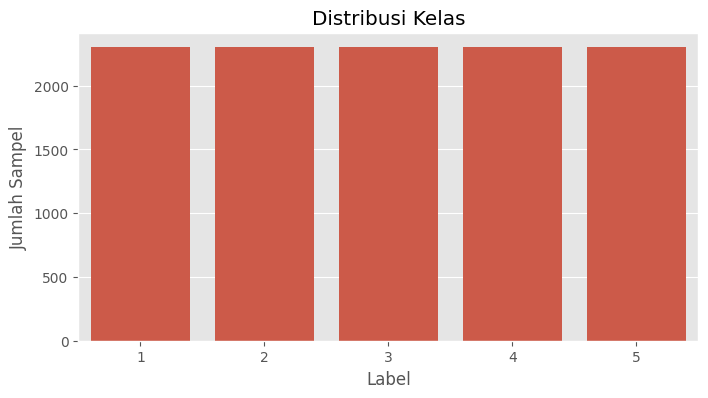

In [7]:

# ============================================================
# BLOK 7 - CEK DISTRIBUSI KELAS
# ============================================================

class_dist = pd.Series(y).value_counts().sort_index()
dist_df = class_dist.reset_index()
dist_df.columns = ["label", "jumlah_sampel"]

display(dist_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=dist_df, x="label", y="jumlah_sampel")
plt.title("Distribusi Kelas")
plt.xlabel("Label")
plt.ylabel("Jumlah Sampel")
plt.show()

## Blok 7

Distribusi kelas dilihat lebih dulu untuk memastikan proporsi data antarkelas. Tahap ini membantu membaca hasil evaluasi sejak awal.

In [8]:

# ============================================================
# BLOK 8 - ENCODE LABEL MENJADI 0 SAMPAI N-1
# ============================================================

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

class_names = [str(c) for c in label_encoder.classes_]
num_classes = len(class_names)

print("Class names :", class_names)
print("Jumlah kelas:", num_classes)

Class names : ['1', '2', '3', '4', '5']
Jumlah kelas: 5


## Blok 8

Label diubah ke format numerik berurutan agar sesuai untuk `SparseCategoricalCrossentropy`. Indeks target menjadi lebih rapi tanpa mengubah urutan kelas asli.

In [9]:

# ============================================================
# BLOK 9 - TRAIN / VALIDATION / TEST SPLIT
# ============================================================

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X,
    y_encoded,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y_encoded
)

val_ratio_adjusted = VAL_SIZE / (1 - TEST_SIZE)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=val_ratio_adjusted,
    random_state=SEED,
    stratify=y_trainval
)

print("Train shape:", X_train.shape, y_train.shape)
print("Val shape  :", X_val.shape, y_val.shape)
print("Test shape :", X_test.shape, y_test.shape)

Train shape: (8050, 178) (8050,)
Val shape  : (1725, 178) (1725,)
Test shape : (1725, 178) (1725,)


## Blok 9

Data dibagi menjadi train, validation, dan test dengan **stratify** agar proporsi kelas tetap terjaga pada setiap subset.

In [10]:

# ============================================================
# BLOK 10 - NORMALISASI PER SAMPEL
# ============================================================

def rowwise_zscore(arr):
    arr = arr.astype("float32")
    mean = arr.mean(axis=1, keepdims=True)
    std = arr.std(axis=1, keepdims=True)
    std = np.where(std < 1e-8, 1.0, std)
    out = (arr - mean) / std
    out = np.clip(out, -5.0, 5.0)
    return out.astype("float32")

X_train_norm = rowwise_zscore(X_train)
X_val_norm   = rowwise_zscore(X_val)
X_test_norm  = rowwise_zscore(X_test)

print("Shape train normalized:", X_train_norm.shape)
print("Contoh mean/std train sample:",
      round(float(X_train_norm[0].mean()), 4),
      round(float(X_train_norm[0].std()), 4))

Shape train normalized: (8050, 178)
Contoh mean/std train sample: 0.0 1.0


## Blok 10

Normalisasi dilakukan **per sampel** agar pola bentuk gelombang tiap segmen lebih menonjol dibandingkan perbedaan skala absolut antarsegmen.

In [11]:

# ============================================================
# BLOK 11 - BENTUK ULANG MENJADI TENSOR SEQUENCE
# ============================================================

sequence_length = X_train_norm.shape[1]

X_train_seq = X_train_norm.reshape(-1, sequence_length, 1)
X_val_seq   = X_val_norm.reshape(-1, sequence_length, 1)
X_test_seq  = X_test_norm.reshape(-1, sequence_length, 1)

y_train_np = np.asarray(y_train).astype("int32")
y_val_np   = np.asarray(y_val).astype("int32")
y_test_np  = np.asarray(y_test).astype("int32")

print("Train sequence shape:", X_train_seq.shape)
print("Val sequence shape  :", X_val_seq.shape)
print("Test sequence shape :", X_test_seq.shape)

Train sequence shape: (8050, 178, 1)
Val sequence shape  : (1725, 178, 1)
Test sequence shape : (1725, 178, 1)


## Blok 11

Model RNN menerima input berbentuk `(jumlah_sampel, panjang_sequence, fitur_per_timestep)`. Karena setiap timestep hanya memuat satu nilai sinyal, dimensi terakhir bernilai 1.

In [12]:

# ============================================================
# BLOK 12 - MEMBUAT TF.DATA PIPELINE
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train_seq, y_train_np))
    .shuffle(buffer_size=min(len(X_train_seq), 4096), seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val_seq, y_val_np))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test_seq, y_test_np))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

I0000 00:00:1776601942.114910      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776601942.120877      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## Blok 12

Pipeline `tf.data` dipakai agar aliran data saat training lebih efisien dan format input tetap konsisten sampai evaluasi.

In [13]:

# ============================================================
# BLOK 13 - MEMBANGUN ARSITEKTUR BiLSTM
# ============================================================

inputs = layers.Input(shape=(sequence_length, 1), name="input_sequence")

x = layers.GaussianNoise(0.02, name="gaussian_noise")(inputs)
x = layers.Dense(
    EMBED_DIM,
    activation="tanh",
    kernel_regularizer=keras.regularizers.l2(L2_FACTOR),
    name="temporal_embedding"
)(x)
x = layers.LayerNormalization(name="ln_embed")(x)
x = layers.SpatialDropout1D(INPUT_DROPOUT, name="spatial_dropout_embed")(x)

x1 = layers.Bidirectional(
    layers.LSTM(
        BILSTM_UNITS_1,
        activation="tanh",
        return_sequences=True,
        dropout=REC_DROPOUT_1,
        recurrent_dropout=0.0,
        kernel_regularizer=keras.regularizers.l2(L2_FACTOR),
    ),
    name="bilstm_1"
)(x)
x1 = layers.LayerNormalization(name="ln_1")(x1)

x2 = layers.Bidirectional(
    layers.LSTM(
        BILSTM_UNITS_2,
        activation="tanh",
        return_sequences=True,
        dropout=REC_DROPOUT_2,
        recurrent_dropout=0.0,
        kernel_regularizer=keras.regularizers.l2(L2_FACTOR),
    ),
    name="bilstm_2"
)(x1)
x2 = layers.LayerNormalization(name="ln_2")(x2)

res_proj = layers.Dense(2 * BILSTM_UNITS_2, name="residual_proj")(x1)
x = layers.Add(name="residual_bilstm")([x2, res_proj])
x = layers.LayerNormalization(name="ln_residual_bilstm")(x)

attn = layers.MultiHeadAttention(
    num_heads=ATTN_HEADS,
    key_dim=ATTN_KEY_DIM,
    dropout=ATTN_DROPOUT,
    name="self_attention"
)(x, x)

x = layers.Add(name="attn_residual")([x, attn])
x = layers.LayerNormalization(name="ln_attn")(x)

ff = layers.Dense(
    FFN_UNITS,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(L2_FACTOR),
    name="ffn_dense_1"
)(x)
ff = layers.Dropout(FFN_DROPOUT, name="ffn_dropout")(ff)
ff = layers.Dense(2 * BILSTM_UNITS_2, name="ffn_dense_2")(ff)

x = layers.Add(name="ffn_residual")([x, ff])
x = layers.LayerNormalization(name="ln_ffn")(x)

avg_pool = layers.GlobalAveragePooling1D(name="gap")(x)
max_pool = layers.GlobalMaxPooling1D(name="gmp")(x)
last_step = layers.Lambda(lambda t: t[:, -1, :], name="last_step")(x)

x = layers.Concatenate(name="concat_pool")([avg_pool, max_pool, last_step])

x = layers.Dense(
    DENSE_UNITS,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(L2_FACTOR),
    name="dense_1"
)(x)
x = layers.BatchNormalization(name="bn_dense")(x)
x = layers.Dropout(DENSE_DROPOUT, name="dropout_dense")(x)

outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)

model = Model(inputs=inputs, outputs=outputs, name=f"{MODEL_NAME}_epileptic_model")

optimizer = keras.optimizers.Adam(
    learning_rate=LEARNING_RATE,
    clipnorm=1.0
)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "BiLSTM_epileptic_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sequence      │ (None, 178, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 178, 1)    │          0 │ input_sequence[0… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_embedding  │ (None, 178, 32)   │         64 │ gaussian_noise[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_embed            │ (None, 178, 32)   │         64 │ temporal_embeddi… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout_em… │ (None, 178, 32)   │          0 │ ln_embed[0][0]    │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 178, 320)  │    247,040 │ spatial_dropout_… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_1                │ (None, 178, 320)  │        640 │ bilstm_1[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 178, 192)  │    320,256 │ ln_1[0][0]        │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_2                │ (None, 178, 192)  │        384 │ bilstm_2[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_proj       │ (None, 178, 192)  │     61,632 │ ln_1[0][0]        │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_bilstm     │ (None, 178, 192)  │          0 │ ln_2[0][0],       │
│ (Add)               │                   │            │ residual_proj[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_residual_bilstm  │ (None, 178, 192)  │        384 │ residual_bilstm[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention      │ (None, 178, 192)  │     74,208 │ ln_residual_bils… │
│ (MultiHeadAttentio… │                   │            │ ln_residual_bils… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_residual (Add) │ (None, 178, 192)  │          0 │ ln_residual_bils… │
│                     │                   │            │ self_attention[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_attn             │ (None, 178, 192)  │        384 │ attn_residual[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_dense_1 (Dense) │ (None, 178, 192)  │     37,056 │ ln_attn[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_dropout         │ (None, 178, 192)  │          0 │ ffn_dense_1[0][0] │
│ (Dropout)           │                   │            │                 

 Total params: 854,565 (3.26 MB)

 Trainable params: 854,309 (3.26 MB)

 Non-trainable params: 256 (1.00 KB)

## Blok 13

Arsitektur memakai **BiLSTM** dengan embedding awal agar setiap timestep tidak hanya dibaca sebagai skalar mentah.  
Bagian tengah memakai **residual connection**, **self-attention**, dan **feed-forward residual block** agar representasi urutan lebih kaya namun tetap stabil saat training.


In [14]:

# ============================================================
# BLOK 14 - CALLBACK TRAINING
# ============================================================

checkpoint_path = f"best_{MODEL_NAME.lower()}_epileptic_v5.keras"

callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=8,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    ),
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True
    )
]

print("Checkpoint path:", checkpoint_path)


Checkpoint path: best_bilstm_epileptic_v5.keras


## Blok 14

Callback dipakai untuk menghentikan training saat validation accuracy tidak lagi membaik, menurunkan learning rate saat validation loss mulai stagnan, dan menyimpan bobot terbaik.


In [15]:

# ============================================================
# BLOK 15 - TRAINING MODEL
# ============================================================

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40


I0000 00:00:1776601956.421570      70 cuda_dnn.cc:529] Loaded cuDNN version 91002


252/252 ━━━━━━━━━━━━━━━━━━━━ 26s 54ms/step - accuracy: 0.4200 - loss: 1.5317 - val_accuracy: 0.4458 - val_loss: 1.6667 - learning_rate: 8.0000e-04
Epoch 2/40
252/252 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.5346 - loss: 1.1621 - val_accuracy: 0.5571 - val_loss: 1.2022 - learning_rate: 8.0000e-04
Epoch 3/40
252/252 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.5905 - loss: 1.0214 - val_accuracy: 0.5919 - val_loss: 1.0140 - learning_rate: 8.0000e-04
Epoch 4/40
252/252 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.6227 - loss: 0.9517 - val_accuracy: 0.6313 - val_loss: 0.9720 - learning_rate: 8.0000e-04
Epoch 5/40
252/252 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.6507 - loss: 0.8850 - val_accuracy: 0.6481 - val_loss: 0.8669 - learning_rate: 8.0000e-04
Epoch 6/40
252/252 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.6662 - loss: 0.8476 - val_accuracy: 0.6330 - val_loss: 0.9335 - learning_rate: 8.0000e-04
Epoch 7/40
252/252 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accurac

## Blok 15

Training dilakukan pada data train dan dipantau menggunakan validation set. Riwayat training disimpan untuk melihat perubahan loss dan accuracy antarepoch.

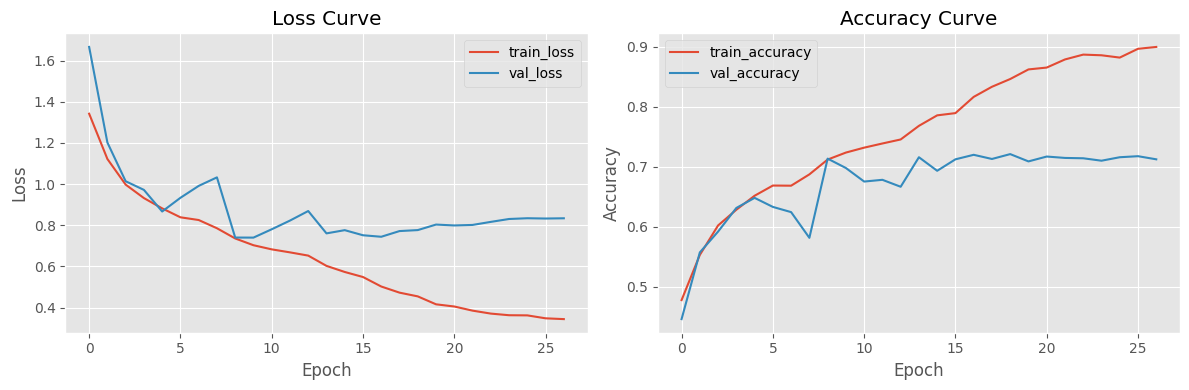

In [16]:

# ============================================================
# BLOK 16 - VISUALISASI LEARNING CURVE
# ============================================================

history_df = pd.DataFrame(history.history)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["accuracy"], label="train_accuracy")
plt.plot(history_df["val_accuracy"], label="val_accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## Blok 16

Kurva training membantu membaca apakah model mulai stabil, underfitting, atau overfitting.

In [17]:

# ============================================================
# BLOK 17 - PREDIKSI PADA DATA TEST
# ============================================================

test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

y_proba = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_proba, axis=1)

print("Test loss     :", round(float(test_loss), 6))
print("Test accuracy :", round(float(test_accuracy), 6))

Test loss     : 0.752626
Test accuracy : 0.703188


## Blok 17

Prediksi probabilitas pada data test diubah menjadi label akhir dengan `argmax`. Tahap ini menghasilkan output utama yang dipakai pada metrik evaluasi.

In [18]:

# ============================================================
# BLOK 18 - MENGHITUNG METRIK EVALUASI
# ============================================================

metrics_dict = {
    "accuracy": accuracy_score(y_test_np, y_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test_np, y_pred),
    "precision_macro": precision_score(y_test_np, y_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test_np, y_pred, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test_np, y_pred, average="macro", zero_division=0),
    "precision_weighted": precision_score(y_test_np, y_pred, average="weighted", zero_division=0),
    "recall_weighted": recall_score(y_test_np, y_pred, average="weighted", zero_division=0),
    "f1_weighted": f1_score(y_test_np, y_pred, average="weighted", zero_division=0),
    "roc_auc_ovr_macro": None,
    "roc_auc_ovr_weighted": None,
}

try:
    metrics_dict["roc_auc_ovr_macro"] = roc_auc_score(
        y_test_np, y_proba, multi_class="ovr", average="macro"
    )
    metrics_dict["roc_auc_ovr_weighted"] = roc_auc_score(
        y_test_np, y_proba, multi_class="ovr", average="weighted"
    )
except Exception as e:
    print("ROC-AUC tidak dapat dihitung:", e)

for k, v in metrics_dict.items():
    print(f"{k:22s}: {None if v is None else round(float(v), 6)}")

accuracy              : 0.703188
balanced_accuracy     : 0.703188
precision_macro       : 0.705219
recall_macro          : 0.703188
f1_macro              : 0.696228
precision_weighted    : 0.705219
recall_weighted       : 0.703188
f1_weighted           : 0.696228
roc_auc_ovr_macro     : 0.938053
roc_auc_ovr_weighted  : 0.938053


## Blok 18

Metrik evaluasi.

Metrik utama yang dicatat:
- accuracy
- balanced accuracy
- precision
- recall
- f1-score
- ROC-AUC multiclass
- test loss

In [19]:

# ============================================================
# BLOK 19 - CLASSIFICATION REPORT
# ============================================================

report = classification_report(
    y_test_np,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

           1     0.9276    0.9652    0.9460       345
           2     0.6818    0.4348    0.5310       345
           3     0.5601    0.6754    0.6124       345
           4     0.6983    0.8319    0.7593       345
           5     0.6583    0.6087    0.6325       345

    accuracy                         0.7032      1725
   macro avg     0.7052    0.7032    0.6962      1725
weighted avg     0.7052    0.7032    0.6962      1725



## Blok 19

Classification report untuk melihat performa tiap kelas secara detail.

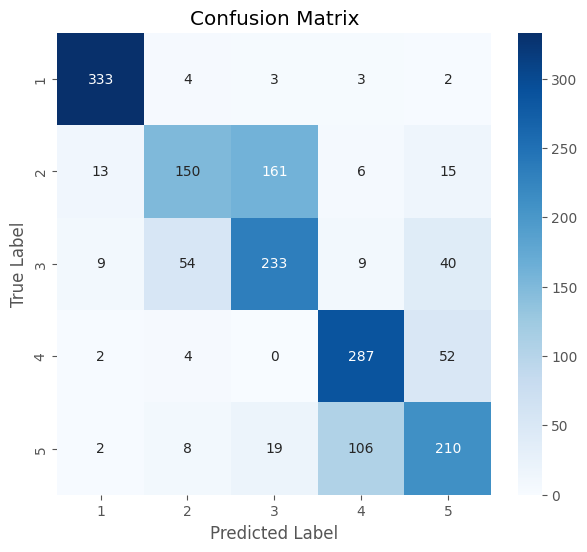

In [20]:

# ============================================================
# BLOK 20 - CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test_np, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Blok 20

Confusion matrix menunjukkan pola prediksi benar dan salah pada setiap kelas sehingga kelas yang sering tertukar bisa terlihat lebih jelas.

In [21]:
# ============================================================
# BLOK 21 - MENYIMPAN HASIL RINGKAS
# ============================================================

results_path = f"results_{MODEL_NAME.lower()}_epileptic_v5.json"

serializable_results = {
    "model": MODEL_NAME,
    "class_names": class_names,
    "metrics": {
        k: (None if v is None else float(v))
        for k, v in metrics_dict.items()
    },
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
}

with open(results_path, "w") as f:
    json.dump(serializable_results, f, indent=2)

print("Results saved to:", results_path)
display(pd.DataFrame([metrics_dict]))

Results saved to: results_bilstm_epileptic_v5.json


,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,roc_auc_ovr_macro,roc_auc_ovr_weighted
0,0.703188,0.703188,0.705219,0.703188,0.696228,0.705219,0.703188,0.696228,0.938053,0.938053


## Blok 21

Hasil evaluasi disimpan ke file JSON agar mudah dipakai kembali saat membuat tabel perbandingan antarmodel.